In [181]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import OneHotEncoder

In [182]:
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

In [183]:
test_df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [184]:
train_df.info()
print('*'*80)
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
********************************************************************************
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------     

In [185]:
#Drop following:
#Name - Not useful
#Ticket - Doesn't matter
#Fare - Doesn't matter
#Cabin - Little to no data on it

#Fill NaN of following:
#age,embarked

#Merge the following feature:
#SibSp and Parch by adding their respective values and naming it 'Members'

#Encode the following:
#Sex,Embarked,Pclass

In [186]:
def clean_df(df):
    df = df.drop(['Name','Ticket','Fare','Cabin'],axis = 1)
    
    df['Age'] = df['Age'].fillna(df['Age'].median())
    df['Embarked'] = df['Embarked'].fillna('S')
    
    df['Members'] = df['SibSp'] + df['Parch']

    ohe = OneHotEncoder(sparse_output=False)
    
    encoded = pd.DataFrame(ohe.fit_transform(df[['Sex']]))
    df = pd.concat([df,encoded],axis = 1)
    df = df.rename(columns={0:'Female',1:'Male'})

    encoded = pd.DataFrame(ohe.fit_transform(df[['Embarked']]))
    df = pd.concat([df,encoded],axis = 1)
    df = df.rename(columns={0:'C',1:'Q',2:'S'})

    encoded = pd.DataFrame(ohe.fit_transform(df[['Pclass']]))
    df = pd.concat([df,encoded],axis = 1)
    df = df.rename(columns={0:'Class1',1:'Class2',2:'Class3'})

    df = df.drop(['Sex','SibSp','Parch','Embarked','Pclass'],axis = 1)
    return df


In [187]:
train_df = clean_df(train_df)
test_df = clean_df(test_df)

In [188]:
train_df.head()

,PassengerId,Survived,Age,Members,Female,Male,C,Q,S,Class1,Class2,Class3
0,1,0,22.0,1,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
1,2,1,38.0,1,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,3,1,26.0,0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3,4,1,35.0,1,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
4,5,0,35.0,0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0


In [189]:
def split_dataset(df):
    df_survived = pd.DataFrame({'PassengerId':[],'Survived':[],'Age':[],'Members':[],'Female':[],'Male':[],'C':[],'Q':[],'S':[],'Class1':[],'Class2':[],'Class3':[]})
    df_not_survived = pd.DataFrame({'PassengerId':[],'Survived':[],'Age':[],'Members':[],'Female':[],'Male':[],'C':[],'Q':[],'S':[],'Class1':[],'Class2':[],'Class3':[]})
    n = df['PassengerId'].size
    for index,survived in zip(range(n),df['Survived']):
        if survived:
            df_survived = pd.concat([df_survived,df.iloc[[index]]])
        elif not survived:
            df_not_survived = pd.concat([df_not_survived,df.iloc[[index]]])
    return(df_survived,df_not_survived)

In [190]:
train_df_survived,train_df_not_survived = split_dataset(train_df)

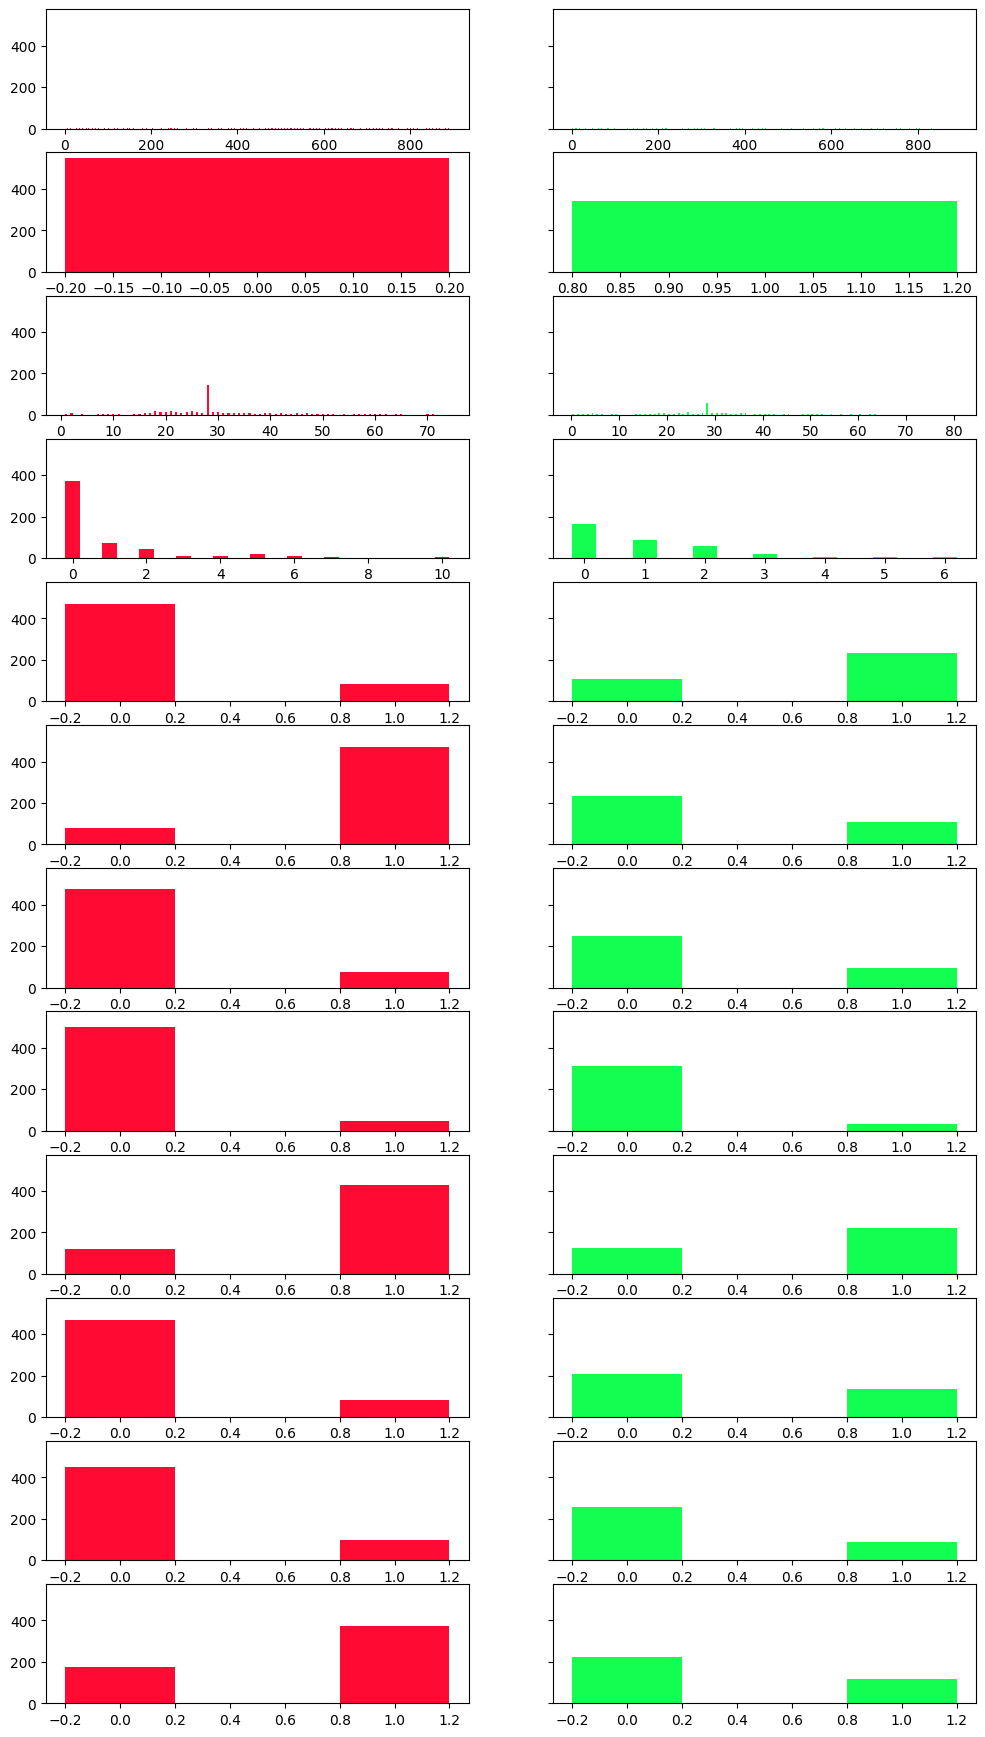

In [191]:
n = len(train_df.columns)
fig,axes = plt.subplots(n,2,figsize = (12,22),sharey = True)
features = ['PassengerId','Survived','Age','Members','Female','Male','C','Q','S','Class1','Class2','Class3']
for i in range(n):
    for survived in range(2):
        ax = axes[i,survived]
        if survived:
            data = train_df_survived[features[i]]
            ax.hist(data,bins = np.arange(data.min(),data.max() + 2) - 0.5,color = '#12ff51',rwidth = 0.4)
        elif not survived:
            data = train_df_not_survived[features[i]]
            ax.hist(data,bins = np.arange(data.min(),data.max() + 2) - 0.5,color = '#ff0a33',rwidth = 0.4)

In [192]:
train_df_survived.head()

,PassengerId,Survived,Age,Members,Female,Male,C,Q,S,Class1,Class2,Class3
1,2.0,1.0,38.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,3.0,1.0,26.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3,4.0,1.0,35.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
8,9.0,1.0,27.0,2.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
9,10.0,1.0,14.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


### Probability of Surviving, given the passenger is Male

In [193]:
s = train_df['Survived'].sum()/train_df['Survived'].size
not_s = 1 - train_df['Survived'].sum()/train_df['Survived'].size

In [194]:
p1 = train_df_survived['Male'].sum()/train_df_survived['Male'].size
p2 = train_df_not_survived['Male'].sum()/train_df_not_survived['Male'].size

In [195]:
P_survived_male = (p1*s)/(p1*s + p2*not_s)

### Probability of Surviving, given the passenger is of age 28

In [196]:
p1 = train_df_survived['Age'].value_counts()[28]/train_df_survived['Age'].size
p2 = train_df_not_survived['Age'].value_counts()[28]/train_df_not_survived['Age'].size

In [197]:
P_survived_age28 = (p1*s)/(p1*s + p2*not_s)

### Probability of Surviving, given the passenger has less than 3 members

In [198]:
p1 = train_df_survived['Members'].value_counts()[[0,1,2]].sum()/train_df_survived['Members'].size
p2 = train_df_not_survived['Members'].value_counts()[[0,1,2]].sum()/train_df_not_survived['Members'].size

In [199]:
P_survived_members3 = (p1*s)/(p1*s+p2*not_s)

### Probability of Surviving, given the passenger embarked in 'C'

In [200]:
p1 = train_df_survived['C'].sum()/train_df_survived['C'].size
p2 = train_df_not_survived['C'].sum()/train_df_not_survived['C'].size

P_survived_C = (p1*s)/(p1*s+p2*not_s)

### Probability of Surviving, given the passenger embarked in 'Q'

In [201]:
p1 = train_df_survived['Q'].sum()/train_df_survived['Q'].size
p2 = train_df_not_survived['Q'].sum()/train_df_not_survived['Q'].size

P_survived_Q = (p1*s)/(p1*s+p2*not_s)

### Probability of Surviving, given the passenger embarked in 'S'

In [202]:
p1 = train_df_survived['S'].sum()/train_df_survived['S'].size
p2 = train_df_not_survived['S'].sum()/train_df_not_survived['S'].size

P_survived_S = (p1*s)/(p1*s+p2*not_s)

### Probability of Surviving, given the passenger is of Class 1

In [203]:
p1 = train_df_survived['Class1'].sum()/train_df_survived['Class1'].size
p2 = train_df_not_survived['Class1'].sum()/train_df_not_survived['Class1'].size

P_survived_Class1 = (p1*s)/(p1*s+p2*not_s)

### Probability of Surviving, given the passenger is of Class 2

In [204]:
p1 = train_df_survived['Class2'].sum()/train_df_survived['Class2'].size
p2 = train_df_not_survived['Class2'].sum()/train_df_not_survived['Class2'].size

P_survived_Class2 = (p1*s)/(p1*s+p2*not_s)

### Probability of Surviving, given the passenger is of Class 3

In [205]:
p1 = train_df_survived['Class3'].sum()/train_df_survived['Class3'].size
p2 = train_df_not_survived['Class3'].sum()/train_df_not_survived['Class3'].size

P_survived_Class1 = (p1*s)/(p1*s+p2*not_s)